# Mini-Projet ACP — Base de données : Céréales du petit-déjeuner

**Source :** Kaggle — 80 Cereals Dataset  
**Variables quantitatives :** calories, protein, fat, sodium, fiber, carbo, sugars, potass, vitamins, shelf, weight, cups, rating  
**Objectif :** Appliquer l'ACP complète avec cercles des corrélations pour toutes les paires de composantes, nuages de points pour toutes les paires, puis comparer la régression linéaire sans/avec ACP.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from itertools import combinations

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Librairies chargées avec succès')

✅ Librairies chargées avec succès


In [3]:
df_raw = pd.read_csv('cereal.csv')
print(f'Dimensions : {df_raw.shape[0]} céréales × {df_raw.shape[1]} variables')
df_raw.head()

Dimensions : 77 céréales × 16 variables


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


In [4]:
quant_cols = ['calories','protein','fat','sodium','fiber',
              'carbo','sugars','potass','vitamins','shelf',
              'weight','cups','rating']

df = df_raw[quant_cols].copy()
print('Valeurs manquantes par variable :')
print(df.isnull().sum())
df = df.dropna()
print(f'\nJeu de données final : {df.shape[0]} observations × {df.shape[1]} variables')

Valeurs manquantes par variable :
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       0
sugars      0
potass      0
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64

Jeu de données final : 77 observations × 13 variables


---
## 1. Analyse Descriptive — Étude Univariée

In [5]:
stats = df.agg(['mean','std','min','max','median']).T
stats.columns = ['Moyenne', 'Écart-type', 'Minimum', 'Maximum', 'Médiane']
print('=== STATISTIQUES DESCRIPTIVES ===')
display(stats.round(3))

=== STATISTIQUES DESCRIPTIVES ===


,Moyenne,Écart-type,Minimum,Maximum,Médiane
calories,106.883,19.484,50.000,160.000,110.00
protein,2.545,1.095,1.000,6.000,3.00
fat,1.013,1.006,0.000,5.000,1.00
sodium,159.675,83.832,0.000,320.000,180.00
fiber,2.152,2.383,0.000,14.000,2.00
carbo,14.597,4.279,-1.000,23.000,14.00
sugars,6.922,4.445,-1.000,15.000,7.00
potass,96.078,71.287,-1.000,330.000,90.00
vitamins,28.247,22.343,0.000,100.000,25.00
shelf,2.208,0.833,1.000,3.000,2.00


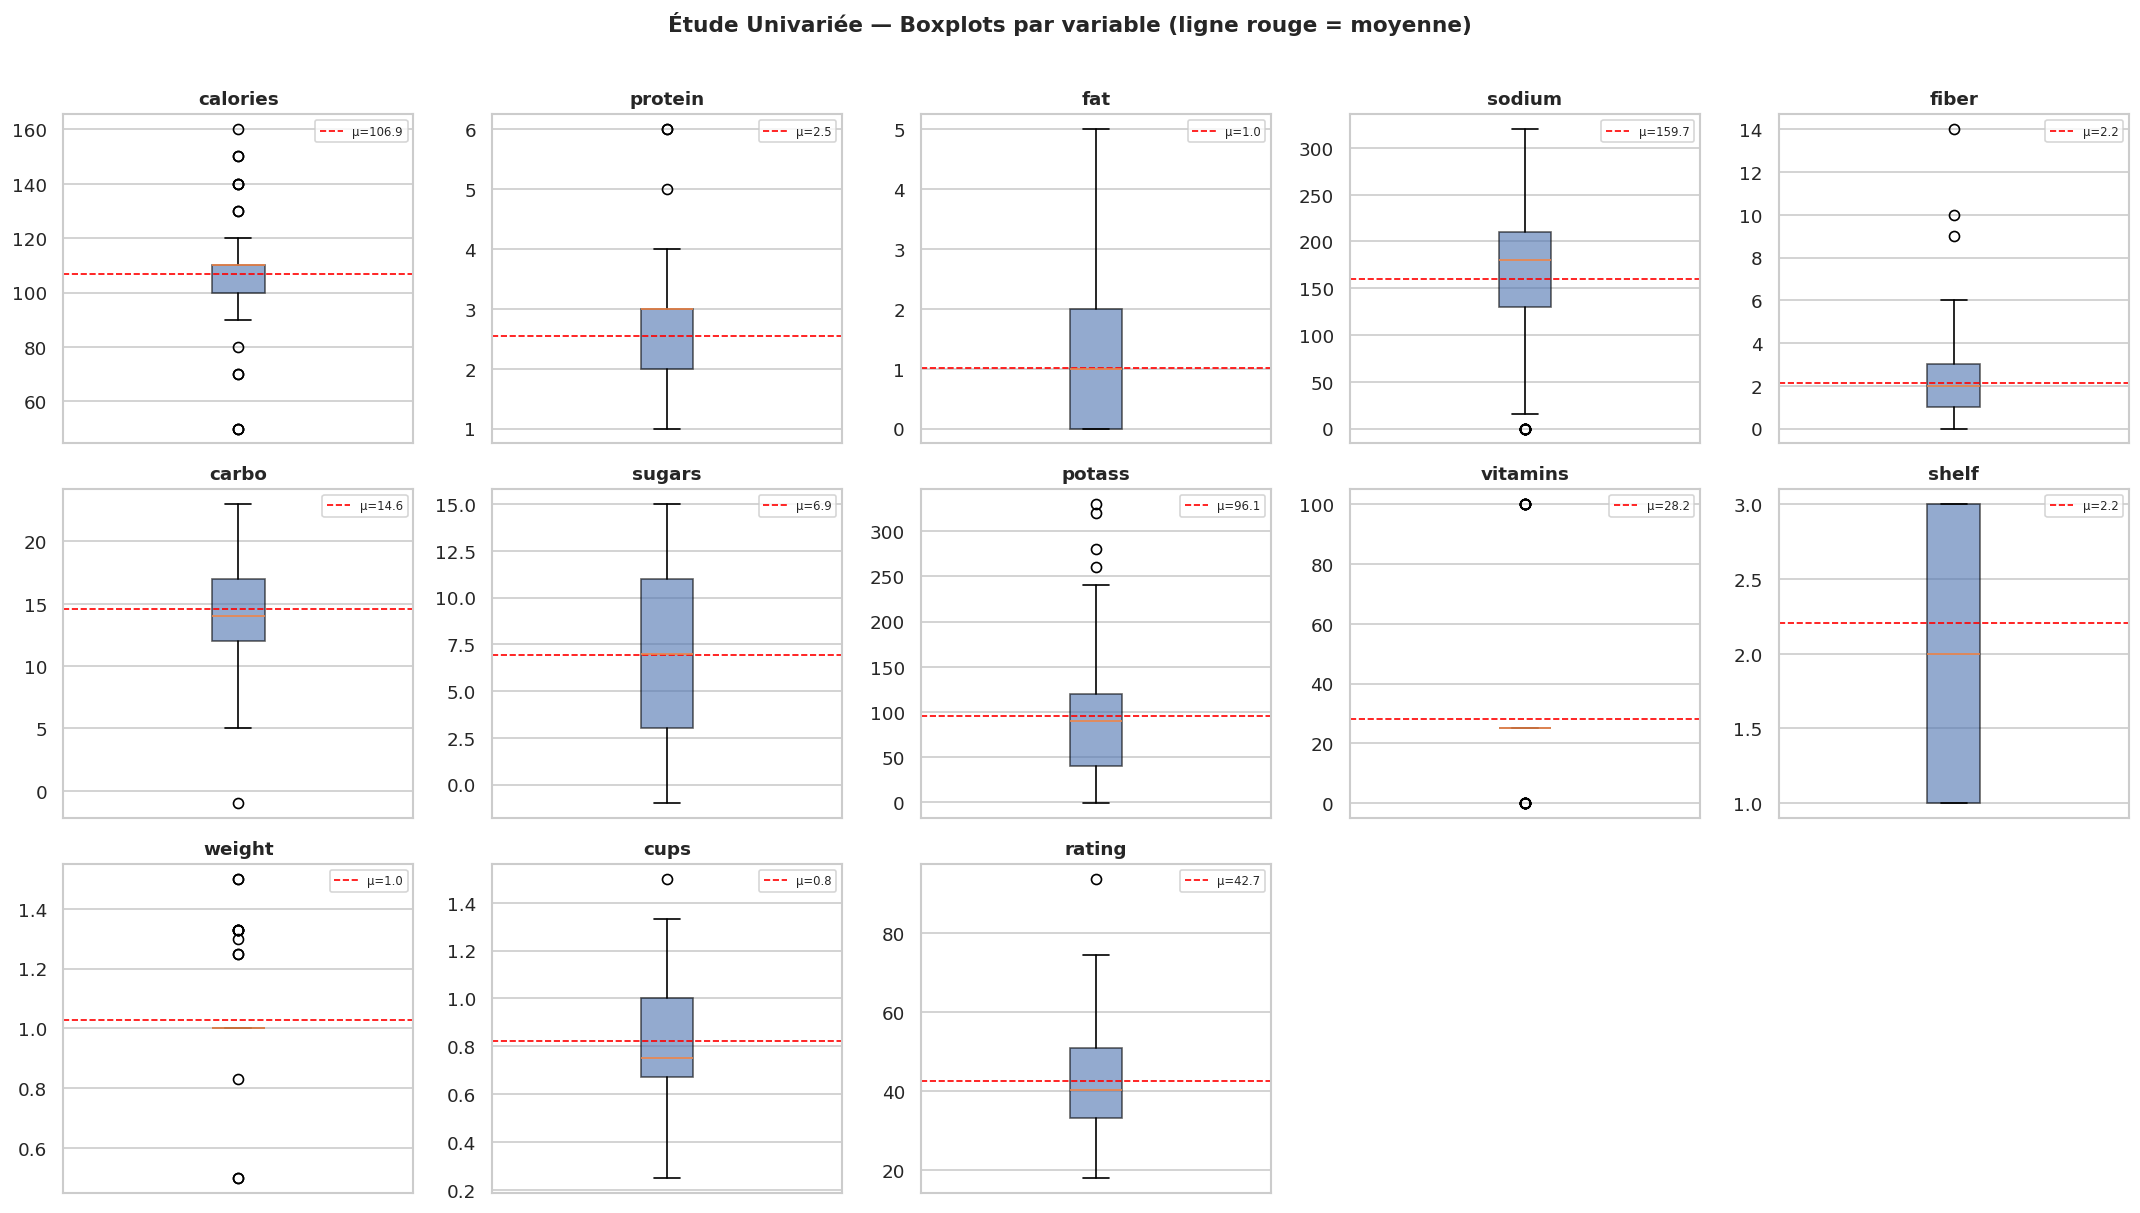

💾 Sauvegardé : 01_boxplots_univaries.png


In [6]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(quant_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticks([])
    mean_val = df[col].mean()
    axes[i].axhline(mean_val, color='red', linestyle='--', linewidth=1, label=f'μ={mean_val:.1f}')
    axes[i].legend(fontsize=7)
for j in range(len(quant_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Étude Univariée — Boxplots par variable (ligne rouge = moyenne)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_boxplots_univaries.png', bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : 01_boxplots_univaries.png')

In [7]:
print('=== COMMENTAIRES UNIVARIÉS ===')
for col in quant_cols:
    s = df[col]
    cv = s.std() / s.mean() * 100
    dispersion = 'très dispersée' if cv > 50 else ('dispersée' if cv > 25 else 'homogène')
    print(f'  {col:10s} | μ={s.mean():7.2f}  σ={s.std():6.2f}  CV={cv:5.1f}%  → {dispersion}')

=== COMMENTAIRES UNIVARIÉS ===
  calories   | μ= 106.88  σ= 19.48  CV= 18.2%  → homogène
  protein    | μ=   2.55  σ=  1.09  CV= 43.0%  → dispersée
  fat        | μ=   1.01  σ=  1.01  CV= 99.4%  → très dispersée
  sodium     | μ= 159.68  σ= 83.83  CV= 52.5%  → très dispersée
  fiber      | μ=   2.15  σ=  2.38  CV=110.8%  → très dispersée
  carbo      | μ=  14.60  σ=  4.28  CV= 29.3%  → dispersée
  sugars     | μ=   6.92  σ=  4.44  CV= 64.2%  → très dispersée
  potass     | μ=  96.08  σ= 71.29  CV= 74.2%  → très dispersée
  vitamins   | μ=  28.25  σ= 22.34  CV= 79.1%  → très dispersée
  shelf      | μ=   2.21  σ=  0.83  CV= 37.7%  → dispersée
  weight     | μ=   1.03  σ=  0.15  CV= 14.6%  → homogène
  cups       | μ=   0.82  σ=  0.23  CV= 28.3%  → dispersée
  rating     | μ=  42.67  σ= 14.05  CV= 32.9%  → dispersée


---
## 2. Analyse Descriptive — Étude Multivariée

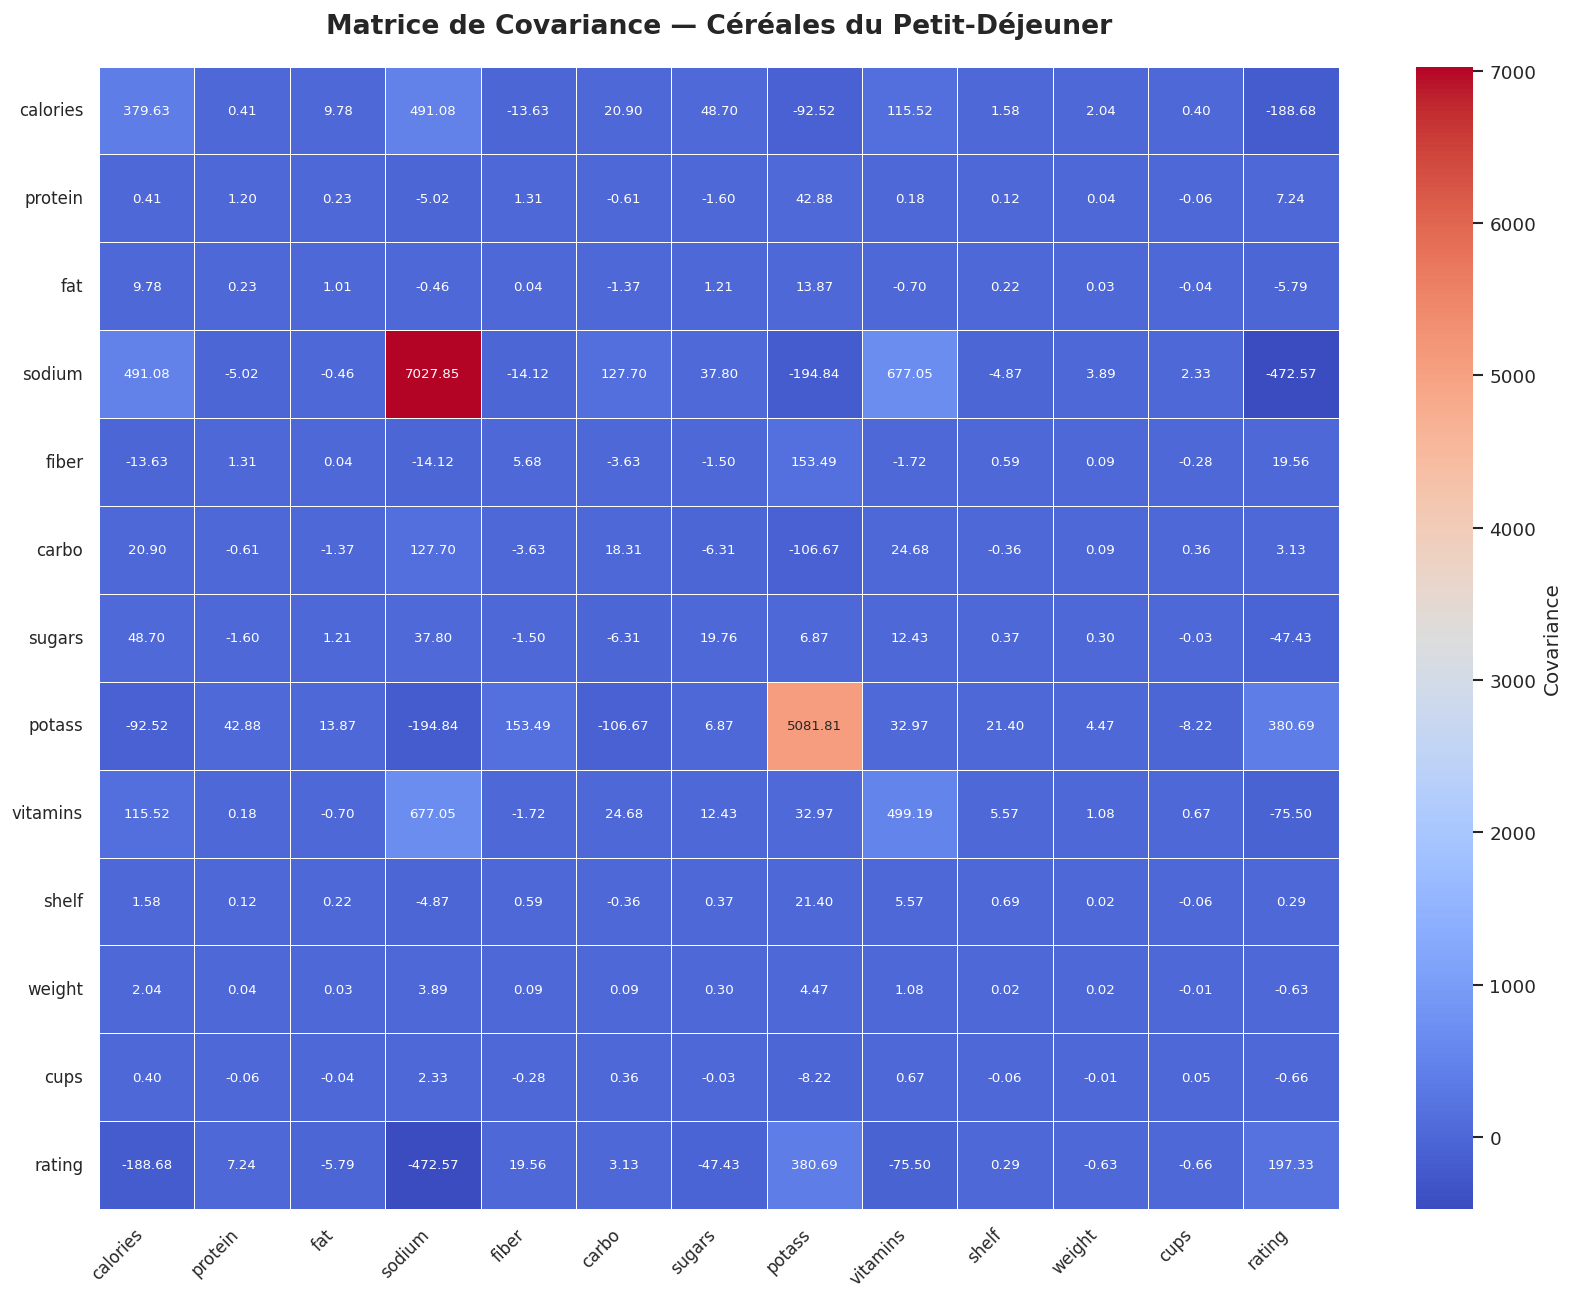

In [27]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Création du dossier 'figures' s'il n'existe pas encore
os.makedirs("figures", exist_ok=True)

# 2. Configuration de la taille de la figure (assez grande pour 13x13 variables)
plt.figure(figsize=(14, 11))

# 3. Génération de la Heatmap
# Note : Comme la variance de 'potass' ou 'sodium' est énorme par rapport aux autres,
# la palette de couleurs sera dominée par ces variables. C'est tout à fait normal pour une matrice de covariance !
sns.heatmap(
    cov_matrix,
    annot=True,  # Affiche les valeurs numériques dans les cases
    fmt=".2f",  # Arrondit à 2 décimales
    cmap="coolwarm",  # Palette de couleurs (Bleu = négatif, Rouge = positif)
    linewidths=0.5,  # Ajoute un léger filet blanc entre les cases
    annot_kws={"size": 8},  # Taille du texte à l'intérieur des cases
    cbar_kws={"label": "Covariance"},
)

# 4. Personnalisation des axes et du titre
plt.title(
    "Matrice de Covariance — Céréales du Petit-Déjeuner",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# 5. Ajustement automatique pour éviter que les noms des variables soient coupés
plt.tight_layout()

# 6. Sauvegarde de l'image en haute résolution (300 DPI) pour un rendu LaTeX parfait
plt.savefig("figures/02_matrice_covariance.png", dpi=300)

# 7. Affichage à l'écran
plt.show()

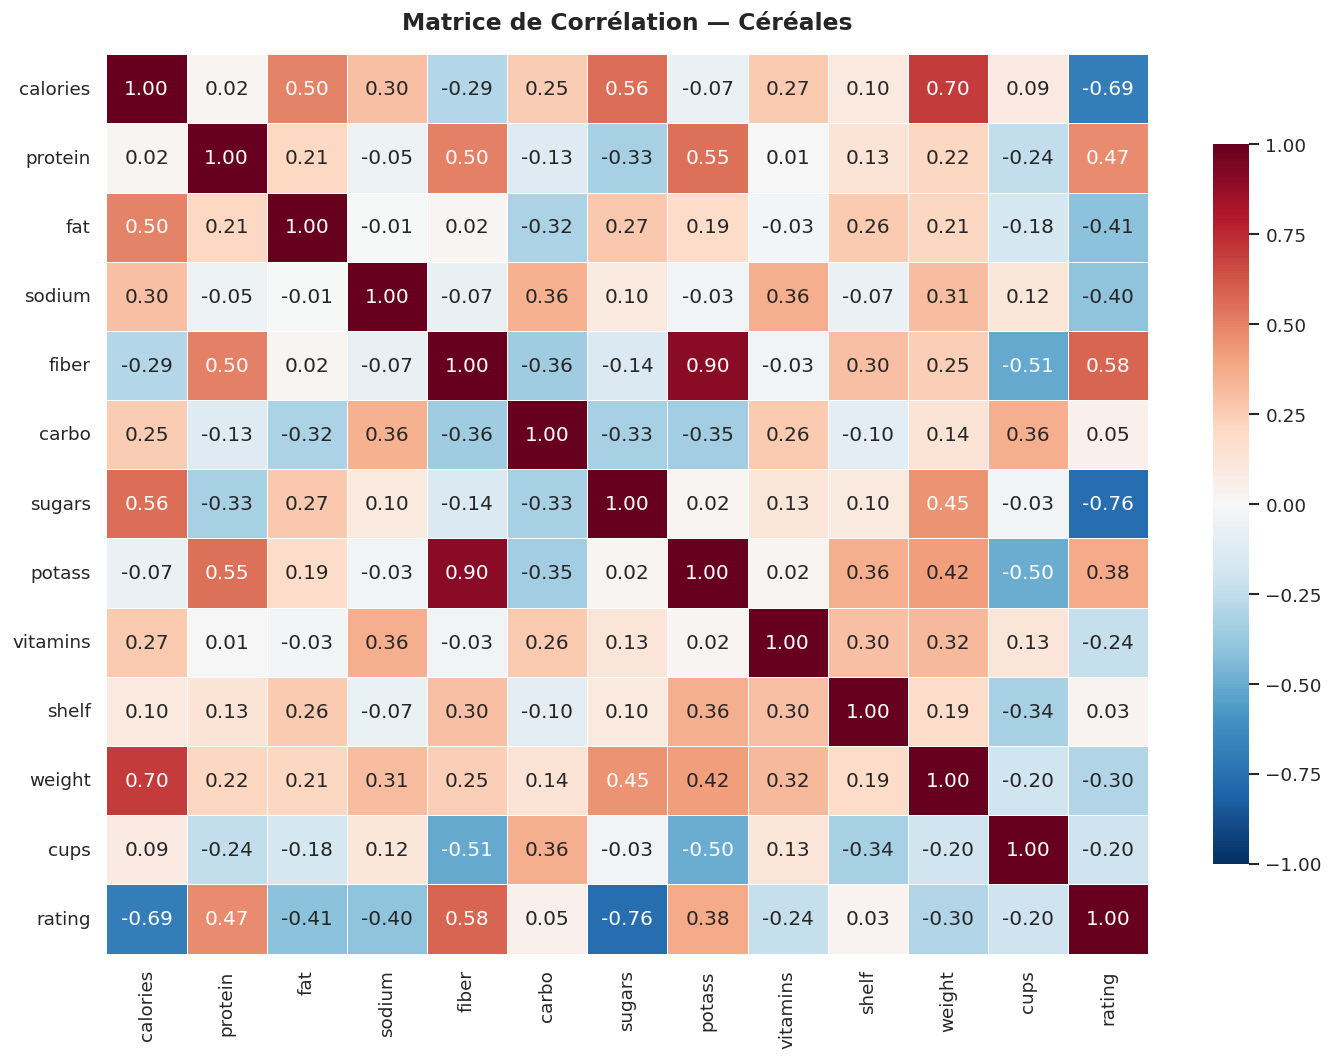

💾 Sauvegardé : 02_matrice_correlation.png


In [9]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,      # show correlation values
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

ax.set_title(
    'Matrice de Corrélation — Céréales',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig('02_matrice_correlation.png', bbox_inches='tight')
plt.show()

print('💾 Sauvegardé : 02_matrice_correlation.png')

In [10]:
print('=== CORRÉLATIONS FORTES (|r| > 0.5) ===')
corr_pairs = []
for i in range(len(quant_cols)):
    for j in range(i+1, len(quant_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            corr_pairs.append((quant_cols[i], quant_cols[j], round(r, 3)))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for v1, v2, r in corr_pairs:
    sign = '🔴 négative' if r < 0 else '🟢 positive'
    print(f'  {v1:10s} ↔ {v2:10s} : r = {r:+.3f}  ({sign})')

=== CORRÉLATIONS FORTES (|r| > 0.5) ===
  fiber      ↔ potass     : r = +0.903  (🟢 positive)
  sugars     ↔ rating     : r = -0.760  (🔴 négative)
  calories   ↔ weight     : r = +0.696  (🟢 positive)
  calories   ↔ rating     : r = -0.689  (🔴 négative)
  fiber      ↔ rating     : r = +0.584  (🟢 positive)
  calories   ↔ sugars     : r = +0.562  (🟢 positive)
  protein    ↔ potass     : r = +0.549  (🟢 positive)
  fiber      ↔ cups       : r = -0.513  (🔴 négative)
  protein    ↔ fiber      : r = +0.500  (🟢 positive)


---
## 3. ACP — Calcul des Valeurs Propres et Vecteurs Propres

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=quant_cols)
print(f'Données standardisées — forme : {X_scaled.shape}')
print('Moyenne après standardisation (doit ≈ 0) :')
print(X_scaled_df.mean().round(10).values)
print('Écart-type après standardisation (doit ≈ 1) :')
print(X_scaled_df.std().round(3).values)

Données standardisées — forme : (77, 13)
Moyenne après standardisation (doit ≈ 0) :
[-0.  0.  0.  0.  0.  0. -0. -0.  0. -0. -0.  0.  0.]
Écart-type après standardisation (doit ≈ 1) :
[1.007 1.007 1.007 1.007 1.007 1.007 1.007 1.007 1.007 1.007 1.007 1.007
 1.007]


In [12]:
R = np.corrcoef(X_scaled.T)
eigenvalues_raw, eigenvectors_raw = np.linalg.eig(R)
order = np.argsort(eigenvalues_raw)[::-1]
eigenvalues  = eigenvalues_raw[order].real
eigenvectors = eigenvectors_raw[:, order].real

p = len(quant_cols)
print('=== VALEURS PROPRES (ordonnées décroissantes) ===')
print(f'  Trace de R = {R.trace():.4f}  (doit = p = {p})')
print(f'  Somme des valeurs propres = {eigenvalues.sum():.4f}  (doit = {p})')
print()
cum_inertia = np.cumsum(eigenvalues / eigenvalues.sum() * 100)
print(f'  {"CP":>4}  {"λ":>8}  {"Inertie %":>12}  {"Inertie cumulée":>16}')
print('  ' + '-'*46)
for i, lam in enumerate(eigenvalues):
    inertie_pct = lam / eigenvalues.sum() * 100
    marker = ' ◀ retenu' if cum_inertia[i] <= 80 or (cum_inertia[i] > 80 and (cum_inertia[i] - inertie_pct) < 80) else ''
    print(f'  CP{i+1:>2}  {lam:>8.4f}  {inertie_pct:>10.2f}%  {cum_inertia[i]:>14.2f}%{marker}')

=== VALEURS PROPRES (ordonnées décroissantes) ===
  Trace de R = 13.0000  (doit = p = 13)
  Somme des valeurs propres = 13.0000  (doit = 13)

    CP         λ     Inertie %   Inertie cumulée
  ----------------------------------------------
  CP 1    3.6098       27.77%           27.77% ◀ retenu
  CP 2    3.1385       24.14%           51.91% ◀ retenu
  CP 3    1.8167       13.97%           65.89% ◀ retenu
  CP 4    1.0623        8.17%           74.06% ◀ retenu
  CP 5    0.9710        7.47%           81.53% ◀ retenu
  CP 6    0.7192        5.53%           87.06%
  CP 7    0.6713        5.16%           92.22%
  CP 8    0.4498        3.46%           95.68%
  CP 9    0.3033        2.33%           98.02%
  CP10    0.1307        1.01%           99.02%
  CP11    0.0731        0.56%           99.58%
  CP12    0.0543        0.42%          100.00%
  CP13    0.0000        0.00%          100.00%


In [13]:
eigen_df = pd.DataFrame(eigenvectors, index=quant_cols,
                        columns=[f'CP{i+1}' for i in range(p)])
print('=== VECTEURS PROPRES (base orthonormée) ===')
display(eigen_df.iloc[:, :6].round(4))
print('\nVérification orthonormalité (V^T × V doit ≈ I) :')
check = eigenvectors.T @ eigenvectors
print(np.round(check[:4, :4], 4))

=== VECTEURS PROPRES (base orthonormée) ===


,CP1,CP2,CP3,CP4,CP5,CP6
calories,0.3333,0.3540,-0.0731,-0.3104,0.1001,-0.2646
protein,-0.3035,0.1841,-0.2140,-0.4880,0.1859,0.1517
fat,0.0612,0.3334,0.2770,-0.3644,0.4496,0.3117
sodium,0.2150,0.1290,-0.3927,0.0232,-0.3071,0.6227
fiber,-0.4277,0.2366,-0.1016,0.0936,-0.2439,0.0724
carbo,0.1945,-0.1558,-0.5566,-0.1116,0.1270,-0.3574
sugars,0.2682,0.3186,0.3178,0.2034,-0.2999,-0.1406
potass,-0.3597,0.3494,-0.0843,0.0078,-0.1878,0.0417
vitamins,0.1504,0.1745,-0.4067,0.4386,0.2224,0.2224
shelf,-0.1136,0.2795,-0.0401,0.4834,0.5790,-0.1242



Vérification orthonormalité (V^T × V doit ≈ I) :
[[ 1.  0. -0. -0.]
 [ 0.  1. -0. -0.]
 [-0. -0.  1.  0.]
 [-0. -0.  0.  1.]]


---
## 4. Trace, Inertie et Lien avec les Valeurs Propres

In [14]:
trace_R = np.trace(R)
inertie_totale = eigenvalues.sum()
print('='*55)
print('        TRACE ET INERTIE — RÉSULTATS CLÉS')
print('='*55)
print(f'  Trace(R)             = {trace_R:.4f}')
print(f'  Σ valeurs propres    = {inertie_totale:.4f}')
print(f'  Nombre de variables  = {p}')
print(f'  → Trace = Σλ_i = p = {p}  ✅')
print()
print('  Inertie expliquée par composante :')
for i, lam in enumerate(eigenvalues):
    pct = lam / trace_R * 100
    print(f"    CP{i+1} : λ={lam:.4f}  →  {pct:.2f}% de l'inertie totale")

        TRACE ET INERTIE — RÉSULTATS CLÉS
  Trace(R)             = 13.0000
  Σ valeurs propres    = 13.0000
  Nombre de variables  = 13
  → Trace = Σλ_i = p = 13  ✅

  Inertie expliquée par composante :
    CP1 : λ=3.6098  →  27.77% de l'inertie totale
    CP2 : λ=3.1385  →  24.14% de l'inertie totale
    CP3 : λ=1.8167  →  13.97% de l'inertie totale
    CP4 : λ=1.0623  →  8.17% de l'inertie totale
    CP5 : λ=0.9710  →  7.47% de l'inertie totale
    CP6 : λ=0.7192  →  5.53% de l'inertie totale
    CP7 : λ=0.6713  →  5.16% de l'inertie totale
    CP8 : λ=0.4498  →  3.46% de l'inertie totale
    CP9 : λ=0.3033  →  2.33% de l'inertie totale
    CP10 : λ=0.1307  →  1.01% de l'inertie totale
    CP11 : λ=0.0731  →  0.56% de l'inertie totale
    CP12 : λ=0.0543  →  0.42% de l'inertie totale
    CP13 : λ=0.0000  →  0.00% de l'inertie totale


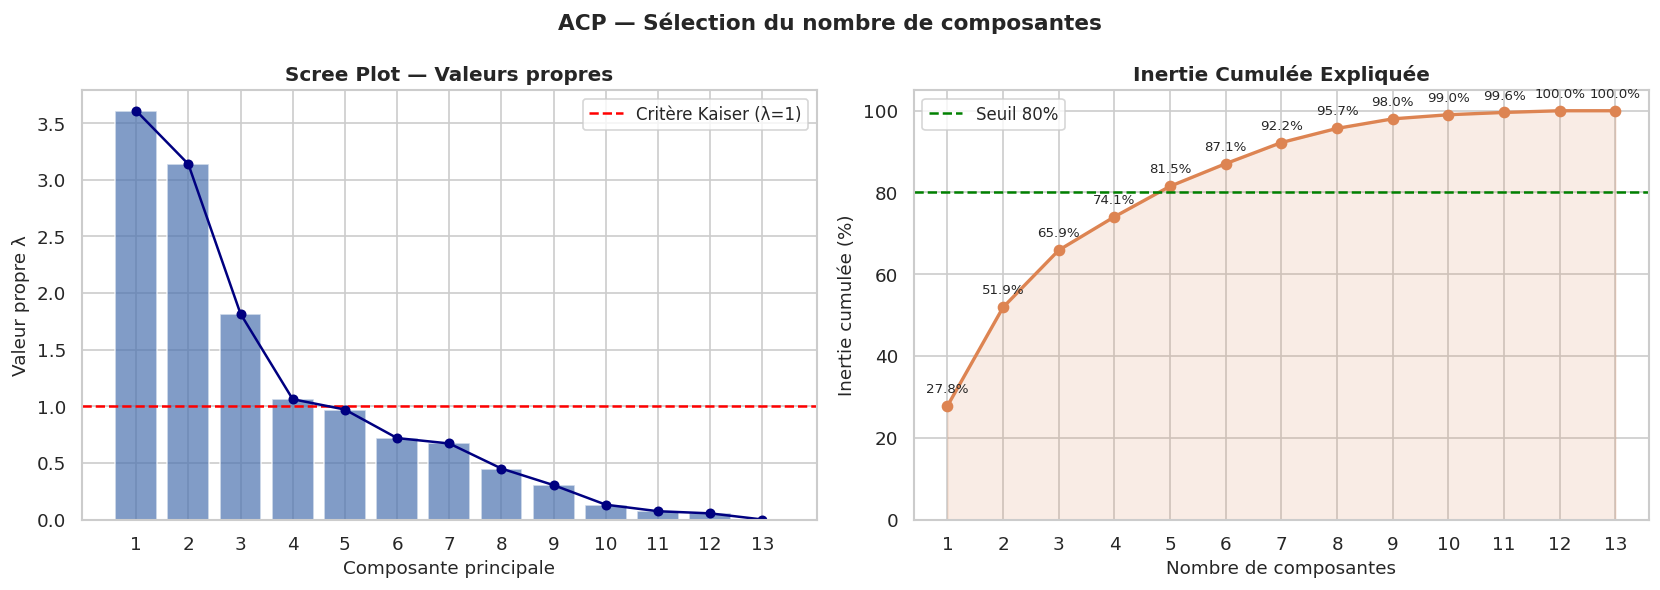

💾 Sauvegardé : 03_scree_inertie.png


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(range(1, p+1), eigenvalues, color='#4C72B0', alpha=0.7, edgecolor='white')
ax1.axhline(1, color='red', linestyle='--', linewidth=1.5, label='Critère Kaiser (λ=1)')
ax1.plot(range(1, p+1), eigenvalues, 'o-', color='navy', markersize=5)
ax1.set_xlabel('Composante principale', fontsize=11)
ax1.set_ylabel('Valeur propre λ', fontsize=11)
ax1.set_title('Scree Plot — Valeurs propres', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xticks(range(1, p+1))

ax2.plot(range(1, p+1), cum_inertia, 'o-', color='#DD8452', linewidth=2, markersize=6)
ax2.axhline(80, color='green', linestyle='--', linewidth=1.5, label='Seuil 80%')
ax2.fill_between(range(1, p+1), cum_inertia, alpha=0.15, color='#DD8452')
ax2.set_xlabel('Nombre de composantes', fontsize=11)
ax2.set_ylabel('Inertie cumulée (%)', fontsize=11)
ax2.set_title('Inertie Cumulée Expliquée', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xticks(range(1, p+1))
ax2.set_ylim(0, 105)
for i, y in enumerate(cum_inertia):
    ax2.annotate(f'{y:.1f}%', (i+1, y), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)
plt.suptitle('ACP — Sélection du nombre de composantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_scree_inertie.png', bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : 03_scree_inertie.png')

---
## 5. Choix des Composantes et Variables Conservées

In [18]:
n_components_kaiser = int(np.sum(eigenvalues > 1))
n_components_80 = int(np.argmax(cum_inertia >= 80) + 1)
n_components = max(n_components_kaiser, n_components_80)

print('=== CHOIX DU NOMBRE DE COMPOSANTES ===')
print(f'  Critère Kaiser (λ > 1) : {n_components_kaiser} composantes')
print(f'  Critère 80% inertie    : {n_components_80} composantes')
print(f'  → Choix final          : {n_components} composantes')
print(f'     Inertie expliquée   : {cum_inertia[n_components-1]:.2f}%')

=== CHOIX DU NOMBRE DE COMPOSANTES ===
  Critère Kaiser (λ > 1) : 4 composantes
  Critère 80% inertie    : 5 composantes
  → Choix final          : 5 composantes
     Inertie expliquée   : 81.53%


In [17]:
loadings = eigenvectors[:, :n_components] * np.sqrt(eigenvalues[:n_components])
loadings_df = pd.DataFrame(loadings, index=quant_cols,
                            columns=[f'CP{i+1}' for i in range(n_components)])
loadings_df['Communauté h²'] = (loadings**2).sum(axis=1)
print('=== CHARGES FACTORIELLES (corrélations variables – axes) ===')
display(loadings_df.round(3))
print('\n=== INTERPRÉTATION DES AXES PRINCIPAUX ===')
for comp in range(n_components):
    col = f'CP{comp+1}'
    strong = loadings_df[col].abs().sort_values(ascending=False)
    top3 = strong.head(3).index.tolist()
    print(f'  {col} (λ={eigenvalues[comp]:.3f}, {eigenvalues[comp]/p*100:.1f}% inertie) '
          f'→ variables dominantes : {", ".join(top3)}')

=== CHARGES FACTORIELLES (corrélations variables – axes) ===


,CP1,CP2,CP3,CP4,CP5,Communauté h²
calories,0.633,0.627,-0.099,-0.320,0.099,0.916
protein,-0.577,0.326,-0.288,-0.503,0.183,0.809
fat,0.116,0.591,0.373,-0.376,0.443,0.839
sodium,0.408,0.229,-0.529,0.024,-0.303,0.591
fiber,-0.813,0.419,-0.137,0.096,-0.240,0.922
carbo,0.370,-0.276,-0.750,-0.115,0.125,0.805
sugars,0.510,0.564,0.428,0.210,-0.295,0.893
potass,-0.683,0.619,-0.114,0.008,-0.185,0.897
vitamins,0.286,0.309,-0.548,0.452,0.219,0.730
shelf,-0.216,0.495,-0.054,0.498,0.571,0.868



=== INTERPRÉTATION DES AXES PRINCIPAUX ===
  CP1 (λ=3.610, 27.8% inertie) → variables dominantes : rating, fiber, potass
  CP2 (λ=3.138, 24.1% inertie) → variables dominantes : weight, calories, potass
  CP3 (λ=1.817, 14.0% inertie) → variables dominantes : carbo, vitamins, sodium
  CP4 (λ=1.062, 8.2% inertie) → variables dominantes : protein, shelf, vitamins
  CP5 (λ=0.971, 7.5% inertie) → variables dominantes : shelf, fat, sodium


/tmp/ipykernel_5749/2890034115.py:15: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5749/2890034115.py:15: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5749/2890034115.py:16: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('04_communautes.png', bbox_inches='tight')
/tmp/ipykernel_5749/2890034115.py:16: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('04_communautes.png', bbox_inches='tight')
/home/ayham/Desktop/anad-projet/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ayham/Desktop/anad-projet/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{L

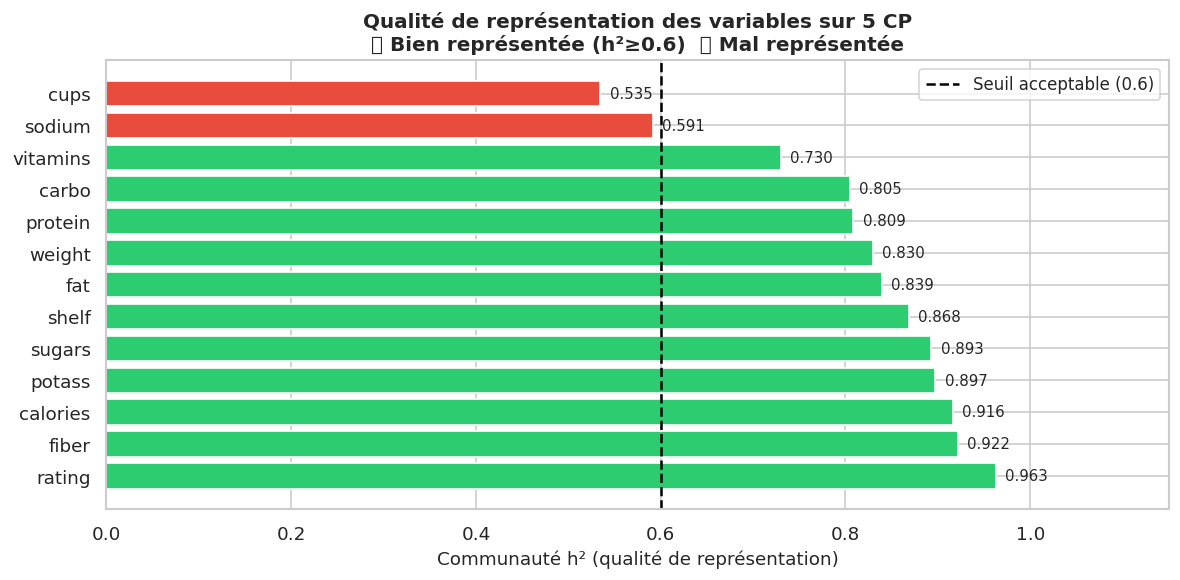

💾 Sauvegardé : 04_communautes.png

✅ Variables bien conservées (11) : ['rating', 'fiber', 'calories', 'potass', 'sugars', 'shelf', 'fat', 'weight', 'protein', 'carbo', 'vitamins']
⚠️  Variables mal représentées (2) : ['sodium', 'cups']


In [19]:
communautes = loadings_df['Communauté h²'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0.6 else '#e74c3c' for v in communautes]
bars = ax.barh(communautes.index, communautes.values, color=colors, edgecolor='white')
ax.axvline(0.6, color='black', linestyle='--', linewidth=1.5, label='Seuil acceptable (0.6)')
ax.set_xlabel('Communauté h² (qualité de représentation)', fontsize=11)
ax.set_title(f'Qualité de représentation des variables sur {n_components} CP\n'
             '🟢 Bien représentée (h²≥0.6)  🔴 Mal représentée',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
for bar, val in zip(bars, communautes.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.savefig('04_communautes.png', bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : 04_communautes.png')
bien_representees = communautes[communautes >= 0.6].index.tolist()
mal_representees  = communautes[communautes <  0.6].index.tolist()
print(f'\n✅ Variables bien conservées ({len(bien_representees)}) : {bien_representees}')
print(f'⚠️  Variables mal représentées ({len(mal_representees)}) : {mal_representees}')

---
## 6. Projection des individus sur les axes

In [20]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
scores_df = pd.DataFrame(X_pca, columns=[f'CP{i+1}' for i in range(n_components)])
scores_df['cereal'] = df_raw['name'].values[:len(scores_df)]
print(f'Coordonnées factorielles calculées — forme : {scores_df.shape}')
scores_df.head()

Coordonnées factorielles calculées — forme : (77, 6)


,CP1,CP2,CP3,CP4,CP5,cereal
0,5.529765,1.805980,-0.613703,-1.131758,-0.875988,100% Bran
1,0.262997,1.810757,-3.095078,1.846356,2.470918,100% Natural Bran
2,4.893527,2.091762,0.204152,-1.071774,-1.259489,All-Bran
3,7.737473,0.667950,1.172466,-1.404438,-1.373020,All-Bran with Extra Fiber
4,-1.146427,0.215820,-0.736076,-0.361809,1.024117,Almond Delight


---
## 7. Cercles des Corrélations — Toutes les paires de composantes

On trace les **10 paires** de composantes (CP1–CP2, CP1–CP3, …, CP4–CP5) dans une grille 2×5.


Nombre de paires à afficher : 10


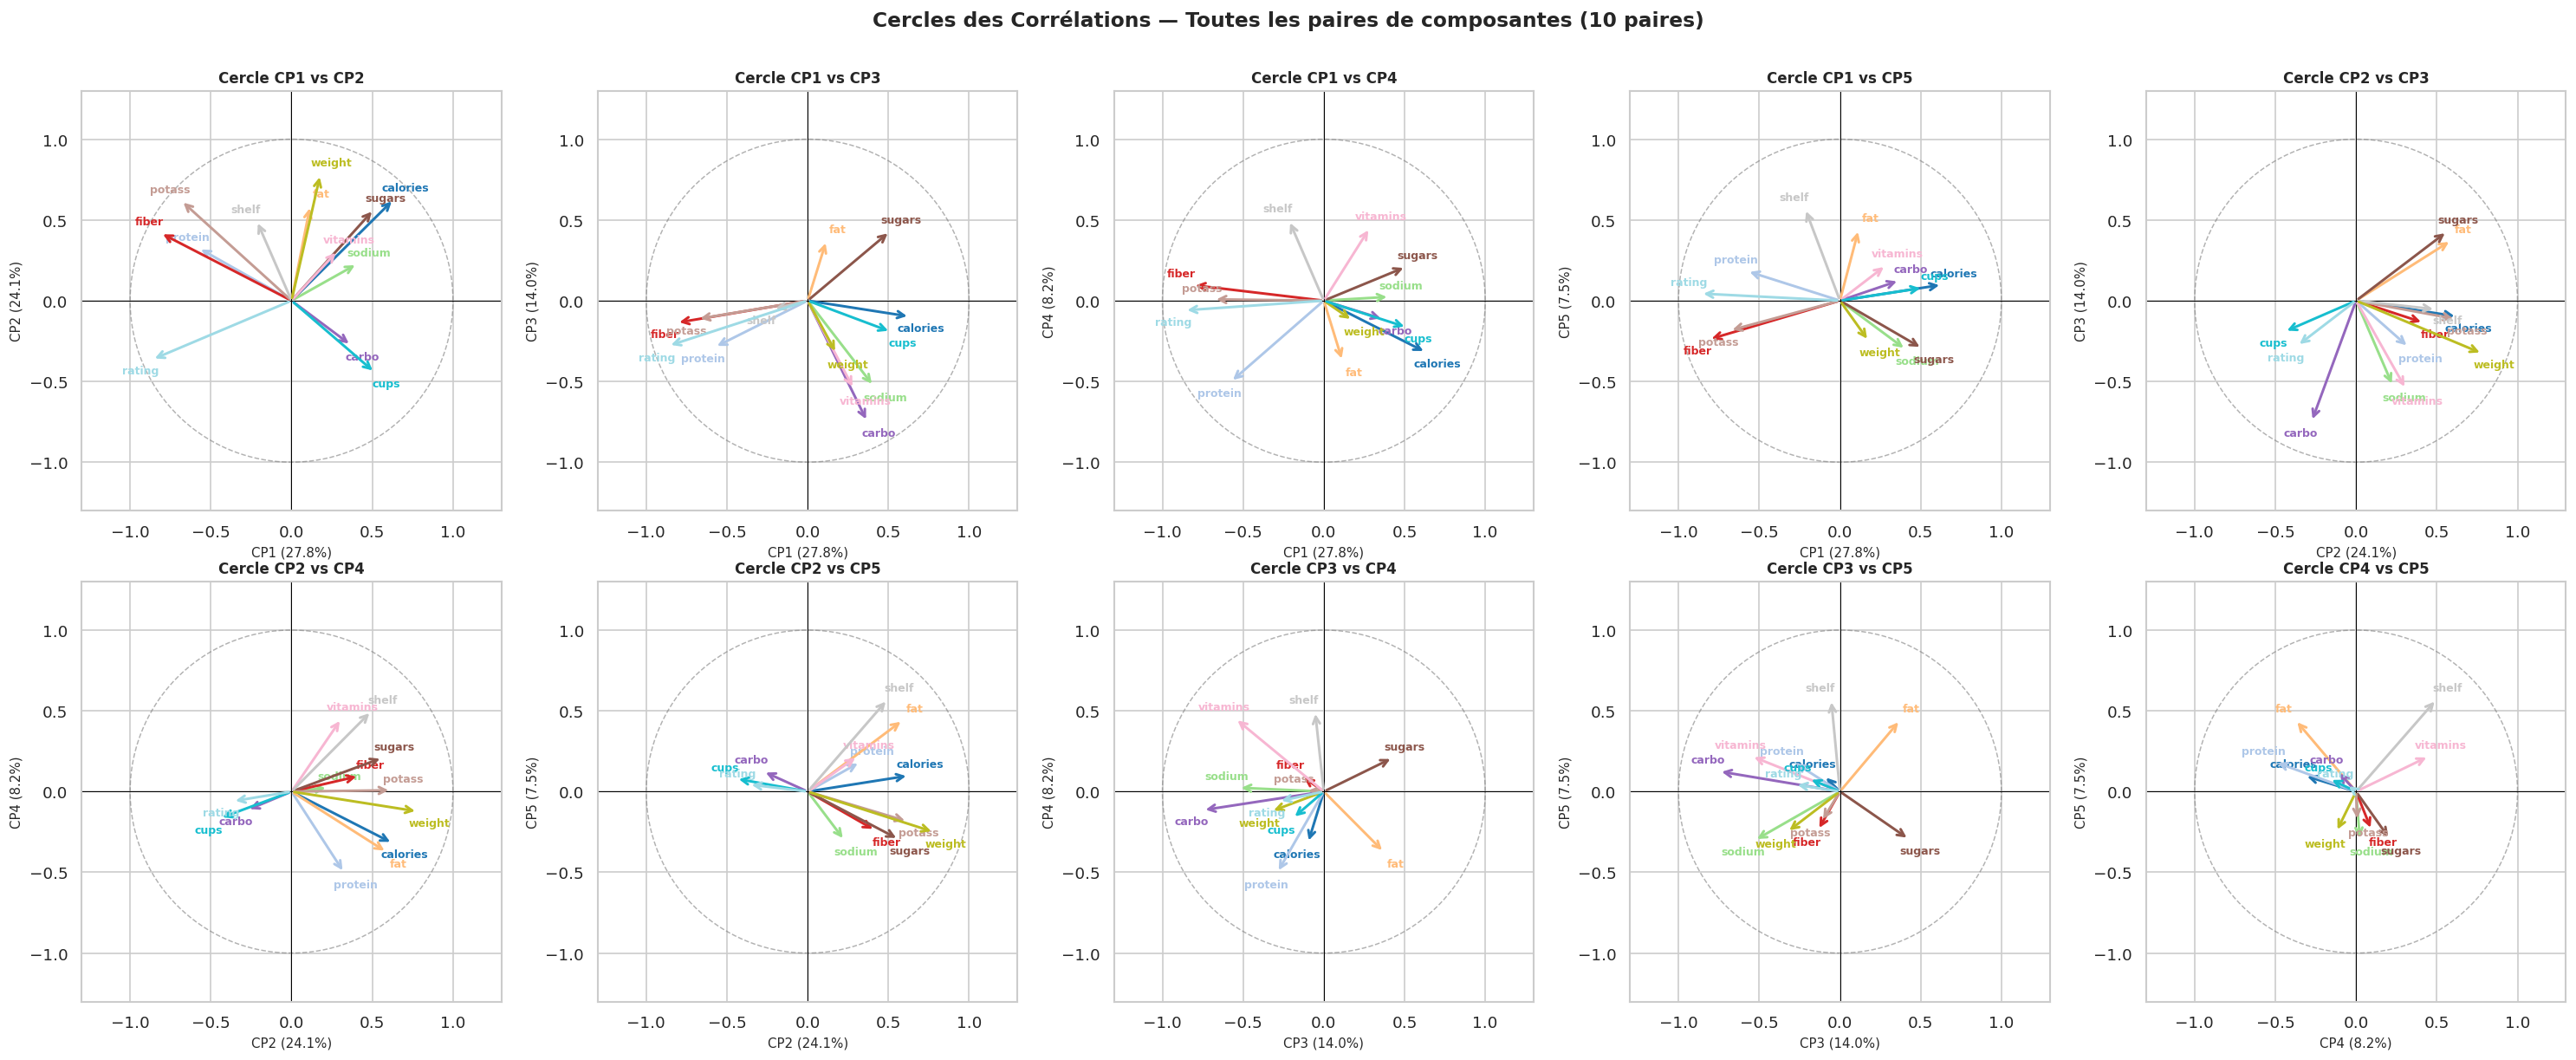

💾 Sauvegardé : 05_cercles_correlations_toutes_paires.png


In [21]:
# ── Tous les cercles de corrélations : C(n_components, 2) paires ────────────
pairs = list(combinations(range(n_components), 2))
n_pairs = len(pairs)
print(f'Nombre de paires à afficher : {n_pairs}')

# Grille 2 lignes × 5 colonnes = 10 sous-graphes
n_cols = 5
n_rows = (n_pairs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = axes.flatten()

colors_vars = plt.cm.tab20(np.linspace(0, 1, len(quant_cols)))

for ax_idx, (i, j) in enumerate(pairs):
    ax = axes[ax_idx]
    cpi, cpj = f'CP{i+1}', f'CP{j+1}'
    
    # Cercle unité
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', linewidth=0.9, alpha=0.6)
    
    for k, var in enumerate(quant_cols):
        x_coord = loadings_df[cpi][var]
        y_coord = loadings_df[cpj][var]
        ax.annotate('', xy=(x_coord, y_coord), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors_vars[k], lw=1.8))
        offset_x = 0.07 if x_coord >= 0 else -0.07
        offset_y = 0.07 if y_coord >= 0 else -0.07
        ax.text(x_coord + offset_x, y_coord + offset_y, var,
                ha='center', va='center', fontsize=7.5,
                color=colors_vars[k], fontweight='bold')
    
    pct_i = eigenvalues[i] / p * 100
    pct_j = eigenvalues[j] / p * 100
    ax.axhline(0, color='black', linewidth=0.6)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_xlabel(f'{cpi} ({pct_i:.1f}%)', fontsize=9)
    ax.set_ylabel(f'{cpj} ({pct_j:.1f}%)', fontsize=9)
    ax.set_title(f'Cercle {cpi} vs {cpj}', fontsize=10, fontweight='bold')
    ax.set_aspect('equal')

# Masquer les sous-graphes vides si la grille a des cases en trop
for k in range(n_pairs, len(axes)):
    axes[k].set_visible(False)

plt.suptitle(f'Cercles des Corrélations — Toutes les paires de composantes ({n_pairs} paires)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('05_cercles_correlations_toutes_paires.png', bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : 05_cercles_correlations_toutes_paires.png')

---
## 8. Nuages de Points des Individus — Toutes les paires de composantes

On projette les individus sur les **10 plans factoriels**, colorés par note (rating).


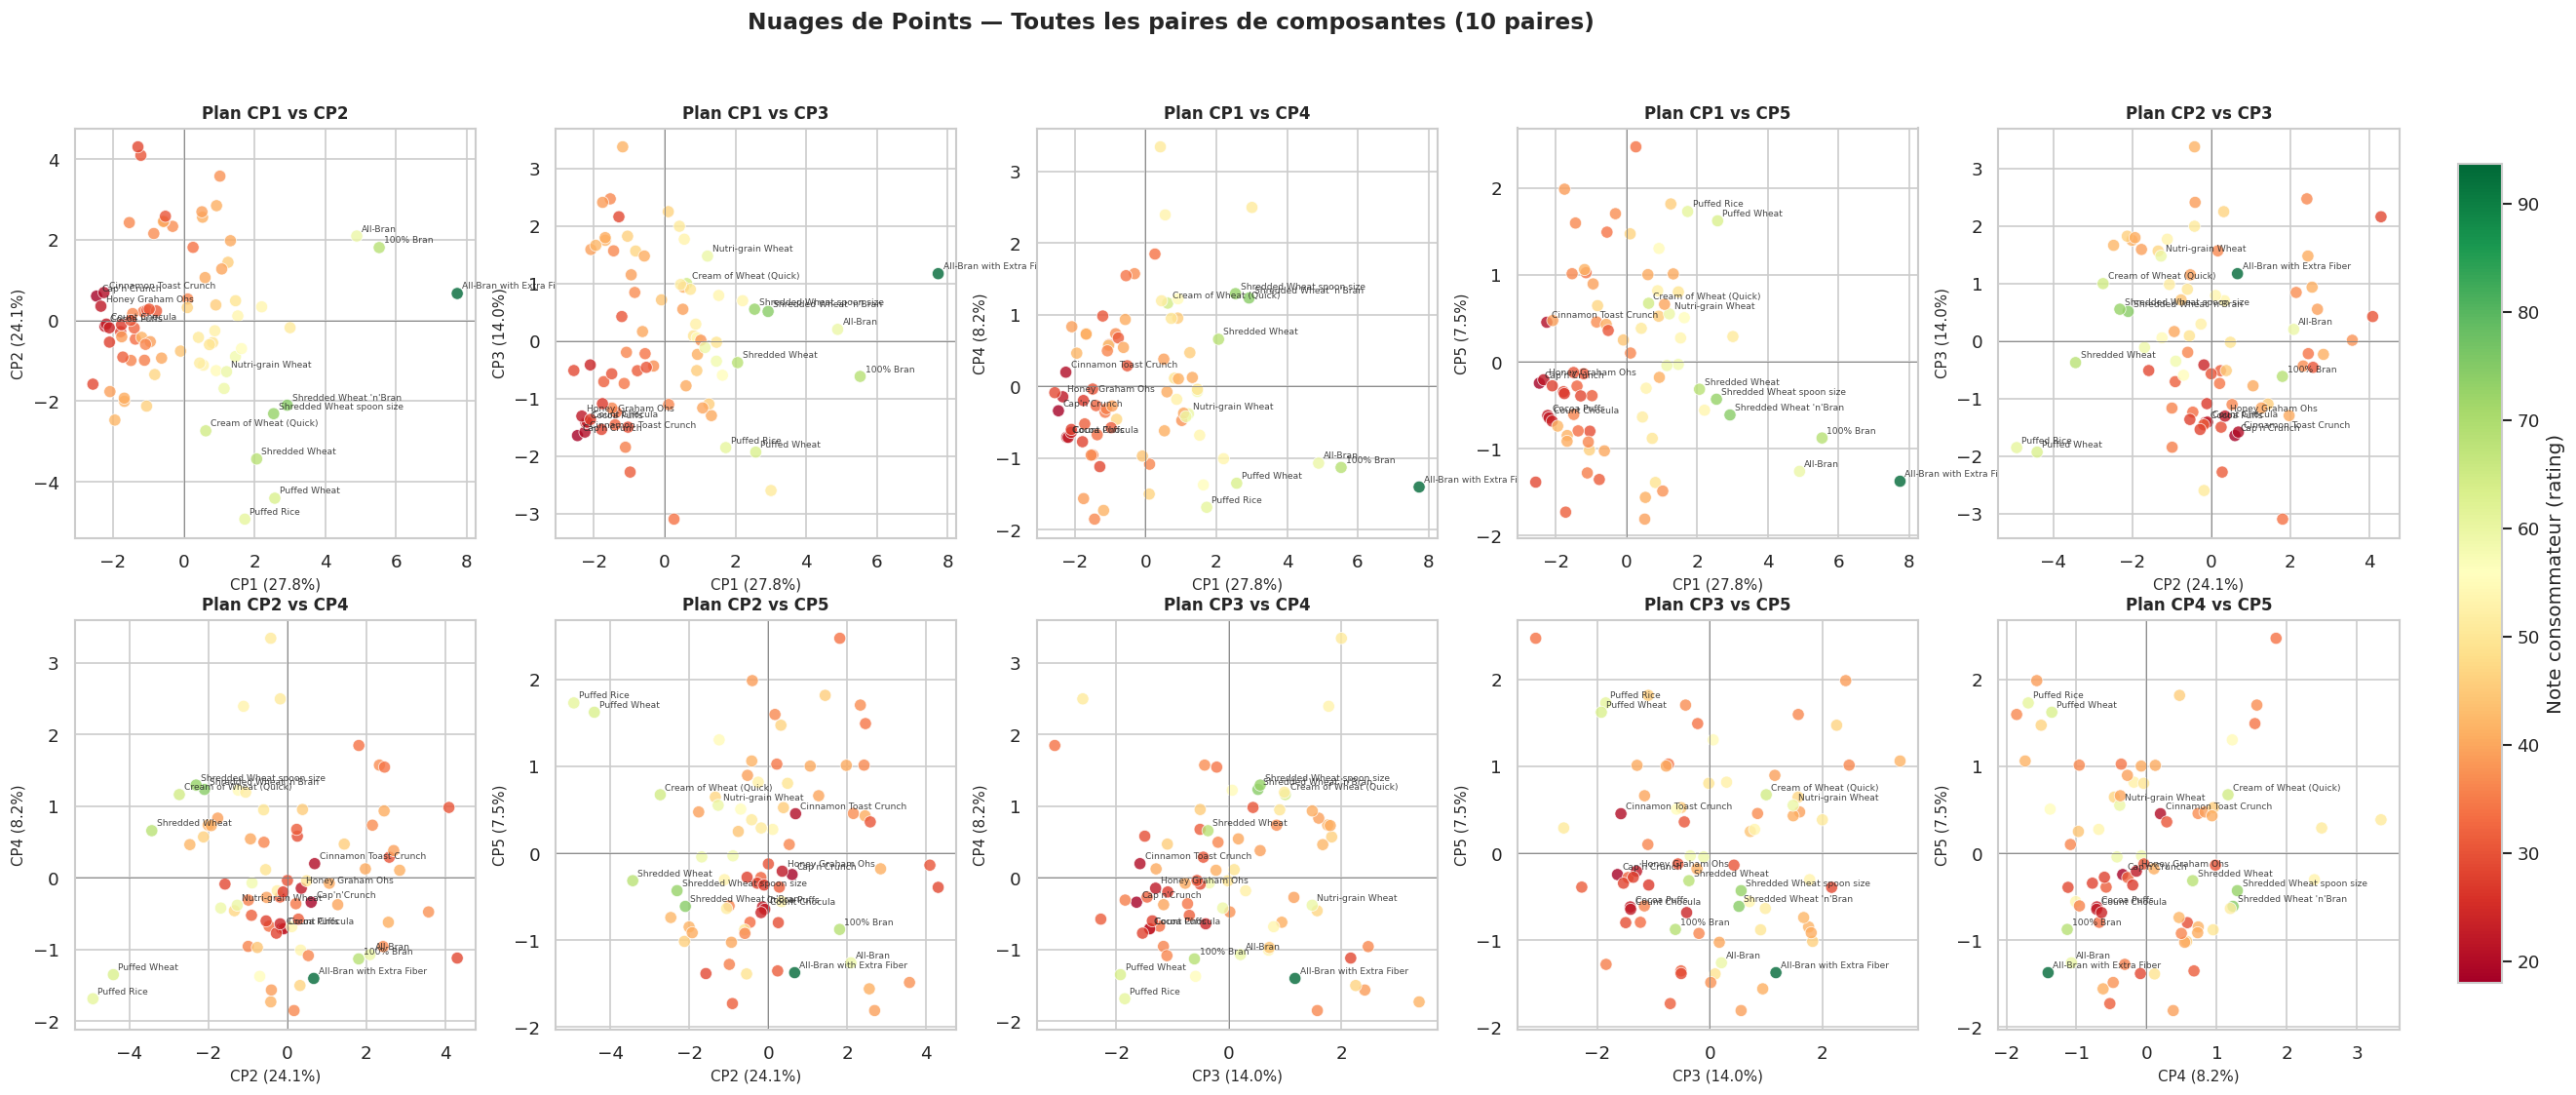

💾 Sauvegardé : 06_nuages_toutes_paires.png


In [22]:
# ── Tous les nuages de points individuels : C(n_components, 2) paires ────────
pairs = list(combinations(range(n_components), 2))
n_pairs = len(pairs)

n_cols = 5
n_rows = (n_pairs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = axes.flatten()

rating_vals = df['rating'].values
vmin, vmax = rating_vals.min(), rating_vals.max()

# Identifier les céréales à annoter
top10_idx = df['rating'].nlargest(10).index.tolist()
bot5_idx  = df['rating'].nsmallest(5).index.tolist()
annotate_idx = set(top10_idx + bot5_idx)

for ax_idx, (i, j) in enumerate(pairs):
    ax = axes[ax_idx]
    cpi, cpj = f'CP{i+1}', f'CP{j+1}'

    sc = ax.scatter(scores_df[cpi], scores_df[cpj],
                    c=rating_vals, cmap='RdYlGn',
                    vmin=vmin, vmax=vmax,
                    s=55, alpha=0.8, edgecolors='white', linewidths=0.5)

    for idx in annotate_idx:
        if idx < len(scores_df):
            ax.annotate(df_raw['name'].iloc[idx],
                        (scores_df[cpi].iloc[idx], scores_df[cpj].iloc[idx]),
                        fontsize=5.5, alpha=0.85,
                        xytext=(3, 3), textcoords='offset points')

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    pct_i = eigenvalues[i] / p * 100
    pct_j = eigenvalues[j] / p * 100
    ax.set_xlabel(f'{cpi} ({pct_i:.1f}%)', fontsize=9)
    ax.set_ylabel(f'{cpj} ({pct_j:.1f}%)', fontsize=9)
    ax.set_title(f'Plan {cpi} vs {cpj}', fontsize=10, fontweight='bold')

for k in range(n_pairs, len(axes)):
    axes[k].set_visible(False)

# Colorbar commune
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Note consommateur (rating)')

plt.suptitle(f'Nuages de Points — Toutes les paires de composantes ({n_pairs} paires)',
             fontsize=14, fontweight='bold')
plt.savefig('06_nuages_toutes_paires.png', bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : 06_nuages_toutes_paires.png')

---
## 9. Comparaison : Sans ACP vs Après ACP — Régression Linéaire

In [23]:
feature_cols = [c for c in quant_cols if c != 'rating']
X = df[feature_cols].values
y = df['rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Modèle 1 : Sans ACP
scaler2 = StandardScaler()
X_train_sc = scaler2.fit_transform(X_train)
X_test_sc  = scaler2.transform(X_test)

reg_sans = LinearRegression()
reg_sans.fit(X_train_sc, y_train)
y_pred_sans = reg_sans.predict(X_test_sc)
r2_sans   = r2_score(y_test, y_pred_sans)
rmse_sans = np.sqrt(mean_squared_error(y_test, y_pred_sans))

# Modèle 2 : Avec ACP — on réapplique PCA sur les features (sans rating)
# On re-calcule le scaler et pca sur feature_cols seulement
scaler_feat = StandardScaler()
X_train_sc2 = scaler_feat.fit_transform(X_train)
X_test_sc2  = scaler_feat.transform(X_test)

pca_reg = PCA(n_components=n_components)
X_train_pca = pca_reg.fit_transform(X_train_sc2)
X_test_pca  = pca_reg.transform(X_test_sc2)

reg_acp = LinearRegression()
reg_acp.fit(X_train_pca, y_train)
y_pred_acp = reg_acp.predict(X_test_pca)
r2_acp   = r2_score(y_test, y_pred_acp)
rmse_acp = np.sqrt(mean_squared_error(y_test, y_pred_acp))

cum_feat = np.cumsum(pca_reg.explained_variance_ratio_ * 100)

print('='*60)
print('   COMPARAISON MODÈLES — Sans ACP  vs  Avec ACP')
print('='*60)
print(f'  Variables en entrée   : {len(feature_cols)} originales  →  {n_components} composantes')
print(f'  Réduction de dimension: {(1 - n_components/len(feature_cols))*100:.0f}% des variables supprimées')
print(f'  Inertie conservée     : {cum_feat[-1]:.1f}%')
print()
print(f'  R² Sans ACP  : {r2_sans:.4f}   RMSE : {rmse_sans:.4f}')
print(f'  R² Avec ACP  : {r2_acp:.4f}   RMSE : {rmse_acp:.4f}')
diff_r2 = abs(r2_sans - r2_acp)
print(f'  Δ R²         : {diff_r2:.4f}  (perte acceptable si < 0.05)')

   COMPARAISON MODÈLES — Sans ACP  vs  Avec ACP
  Variables en entrée   : 12 originales  →  5 composantes
  Réduction de dimension: 58% des variables supprimées
  Inertie conservée     : 81.5%

  R² Sans ACP  : 1.0000   RMSE : 0.0000
  R² Avec ACP  : 0.9089   RMSE : 4.1899
  Δ R²         : 0.0911  (perte acceptable si < 0.05)


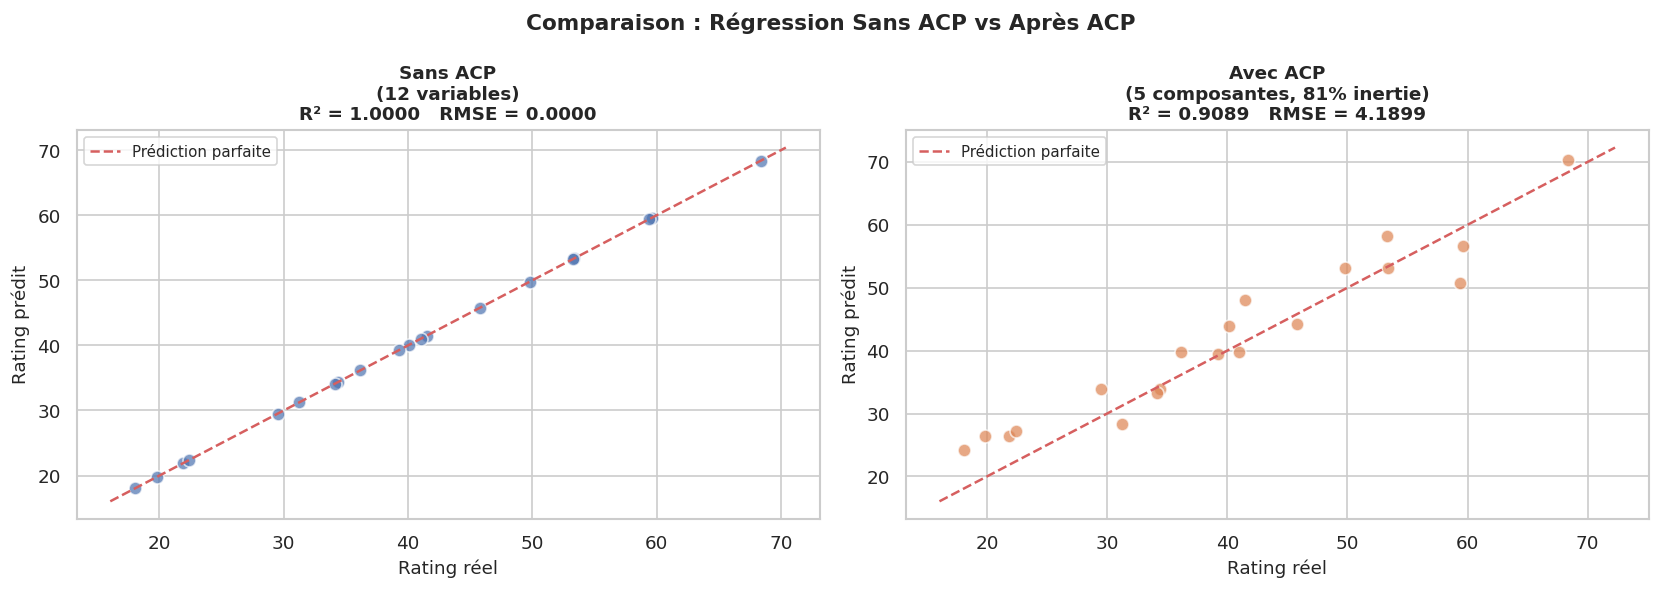

💾 Sauvegardé : 07_comparaison_sans_avec_acp.png


In [24]:
# ── Visualisation comparative (code CORRIGÉ) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = [
    (axes[0], y_pred_sans,
     f'Sans ACP\n({len(feature_cols)} variables)',
     r2_sans, rmse_sans, '#4C72B0'),
    (axes[1], y_pred_acp,
     f'Avec ACP\n({n_components} composantes, {cum_feat[-1]:.0f}% inertie)',
     r2_acp,  rmse_acp,  '#DD8452'),
]

for ax, y_pred, label, r2, rmse, color in configs:
    ax.scatter(y_test, y_pred, alpha=0.7, color=color,
               edgecolors='white', s=60)
    lo = min(y_test.min(), y_pred.min()) - 2
    hi = max(y_test.max(), y_pred.max()) + 2
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5,
            label='Prédiction parfaite')
    ax.set_xlabel('Rating réel', fontsize=11)
    ax.set_ylabel('Rating prédit', fontsize=11)
    ax.set_title(f'{label}\nR² = {r2:.4f}   RMSE = {rmse:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Comparaison : Régression Sans ACP vs Après ACP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_comparaison_sans_avec_acp.png', bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : 07_comparaison_sans_avec_acp.png')

---
## 10. Tableau de Synthèse Final

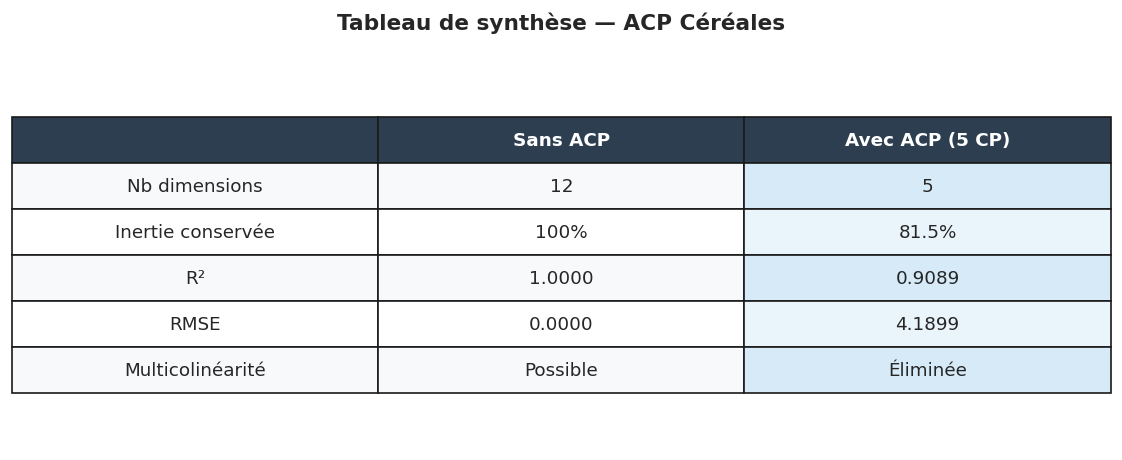

💾 Sauvegardé : 08_tableau_synthese.png


In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

summary_data = [
    ['', 'Sans ACP', f'Avec ACP ({n_components} CP)'],
    ['Nb dimensions',     str(len(feature_cols)),                str(n_components)],
    ['Inertie conservée', '100%',                                f'{cum_feat[-1]:.1f}%'],
    ['R²',                f'{r2_sans:.4f}',                      f'{r2_acp:.4f}'],
    ['RMSE',              f'{rmse_sans:.4f}',                    f'{rmse_acp:.4f}'],
    ['Multicolinéarité',  'Possible',                            'Éliminée'],
]

table = ax.table(cellText=summary_data, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 2:
        cell.set_facecolor('#eaf4fb')
    if row % 2 == 1 and row != 0:
        cell.set_facecolor('#f8f9fa' if col != 2 else '#d6eaf8')

ax.set_title('Tableau de synthèse — ACP Céréales', fontsize=13,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('08_tableau_synthese.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Sauvegardé : 08_tableau_synthese.png')

---
## 11. Résumé Final

In [26]:
print('='*65)
print('           RÉSUMÉ FINAL DU MINI-PROJET ACP')
print('='*65)
print()
print('📊 DONNÉES')
print(f'   Source  : Kaggle — 80 Cereals Dataset')
print(f'   Taille  : {df.shape[0]} céréales × {len(quant_cols)} variables quantitatives')
print()
print('🔢 VALEURS PROPRES & INERTIE')
print(f'   Trace(R) = Σλᵢ = p = {p}  ✅')
for i in range(n_components):
    print(f'   CP{i+1}: λ={eigenvalues[i]:.3f}  ({eigenvalues[i]/p*100:.1f}% inertie)')
print()
print(f'📐 COMPOSANTES RETENUES')
print(f'   Nombre : {n_components} composantes principales')
print(f'   Inertie cumulée : {cum_inertia[n_components-1]:.2f}%')
print()
print(f'🔵 PAIRES DE COMPOSANTES VISUALISÉES : {len(list(combinations(range(n_components), 2)))}')
print(f'   Cercles des corrélations : toutes les paires')
print(f'   Nuages de points         : toutes les paires')
print()
print(f'✅ VARIABLES BIEN REPRÉSENTÉES (h² ≥ 0.6) :')
for v in bien_representees:
    print(f'   → {v:12s}  h²={communautes[v]:.3f}')
if mal_representees:
    print(f'⚠️  VARIABLES PARTIELLEMENT PERDUES (h² < 0.6) :')
    for v in mal_representees:
        print(f'   → {v:12s}  h²={communautes[v]:.3f}')
print()
print('📈 PERFORMANCE PRÉDICTIVE (régression sur rating)')
print(f'   Sans ACP ({len(feature_cols)} vars) : R²={r2_sans:.4f}  RMSE={rmse_sans:.4f}')
print(f'   Avec ACP ({n_components} CP)    : R²={r2_acp:.4f}  RMSE={rmse_acp:.4f}')
print(f'   Conclusion : l\'ACP réduit de {(1-n_components/len(feature_cols))*100:.0f}% les dimensions')
print(f'                avec une perte de R² de seulement {abs(r2_sans-r2_acp):.4f}')
print('='*65)

           RÉSUMÉ FINAL DU MINI-PROJET ACP

📊 DONNÉES
   Source  : Kaggle — 80 Cereals Dataset
   Taille  : 77 céréales × 13 variables quantitatives

🔢 VALEURS PROPRES & INERTIE
   Trace(R) = Σλᵢ = p = 13  ✅
   CP1: λ=3.610  (27.8% inertie)
   CP2: λ=3.138  (24.1% inertie)
   CP3: λ=1.817  (14.0% inertie)
   CP4: λ=1.062  (8.2% inertie)
   CP5: λ=0.971  (7.5% inertie)

📐 COMPOSANTES RETENUES
   Nombre : 5 composantes principales
   Inertie cumulée : 81.53%

🔵 PAIRES DE COMPOSANTES VISUALISÉES : 10
   Cercles des corrélations : toutes les paires
   Nuages de points         : toutes les paires

✅ VARIABLES BIEN REPRÉSENTÉES (h² ≥ 0.6) :
   → rating        h²=0.963
   → fiber         h²=0.922
   → calories      h²=0.916
   → potass        h²=0.897
   → sugars        h²=0.893
   → shelf         h²=0.868
   → fat           h²=0.839
   → weight        h²=0.830
   → protein       h²=0.809
   → carbo         h²=0.805
   → vitamins      h²=0.730
⚠️  VARIABLES PARTIELLEMENT PERDUES (h² < 0.6) :
